# CS6140 Machine Learning — Fall 2026
# HW2 Starter — Gradient Descent, L1/Lasso, Perceptron, Boosting for Classification, Active Learning

This notebook implements `HW2_26F.html`. Where a well-known library offers the same functionality
you'll run it first as a sanity-check baseline, then implement the same thing from scratch and
evaluate it exactly the same way, so your two numbers should land right next to each other once
everything is filled in.

**Problems 1-5 (required):**
1. Gradient descent: L2-regularized linear regression + logistic regression (Housing, Spambase)
2. L1 / Lasso regularization and feature selection (Spambase, Housing, 20 Newsgroups)
3. Perceptron from scratch (linearly-separable toy data)
4. Gradient boosting for classification, reusing the HW1 decision tree (Spambase; multiclass
   Newsgroups stretch)
5. Active learning by uncertainty sampling, reusing the classifiers from Problems 1 and 4

**Problem 6 (optional, no credit):**
6. Lasso from scratch by coordinate descent, verified against sklearn's `Lasso`

**How to work through this notebook.** Everything runs except the lines marked
`### TODO_STUDENT ###` — those have their code replaced with a `...` placeholder and a one-line
description of what to implement there. Read the surrounding (working) code and the markdown above
each section for context, then replace each `...` with real code. A cell with a `...` in it will
raise a `SyntaxError` or produce obviously wrong output until you fill it in — that's expected, not
a bug. Work top to bottom: Problem 4's boosting reuses the `DecisionTree` class you fill in earlier
in that same problem; Problem 5 reuses the logistic regression from Problem 1 and the
gradient-boosted classifier from Problem 4, so finish those `TODO`s first. Problem 2 is entirely
library code (no from-scratch component) and Problem 6 is a standalone optional problem that only
needs Problem 1's Spambase data and the `Lasso` import from Problem 2. Once a "library baseline"
cell's TODOs are filled in and run, the printed number is a target: your matching "from scratch"
implementation just below it should land on (or very near) the same value.

Datasets are read from the shared course `data/` folder (paths are relative to
`2_GD_REG_pton_NN/code_hw/`, i.e. two levels up).

**Requirements.**
1. Fill in every `TODO_STUDENT` blank according to the algorithm steps covered in lecture and the
   linked materials, and make sure the notebook runs top to bottom without errors.
2. Understand the *whole* notebook — including the provided/given code, not just the blanks you
   filled in — well enough to explain any part of it during office hours.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error as mse_loss

DATA = "../data"
np.random.seed(42)


## Data loading\n\nHousing comes pre-split (regression). Spambase is one file, so we split it ourselves -- same convention as HW1. Both are standardized using *training* statistics only (per the assignment's normalization note), applied to train and test alike.

In [35]:
# ---- Housing (regression): already split into train/test by the course ----
train_housing = np.loadtxt(f"{DATA}/housing_train.txt")
test_housing = np.loadtxt(f"{DATA}/housing_test.txt")

X_train_housing, y_train_housing = train_housing[:, :-1], train_housing[:, -1]
X_test_housing, y_test_housing = test_housing[:, :-1], test_housing[:, -1]

housing_scaler = StandardScaler().fit(X_train_housing)
X_train_housing = housing_scaler.transform(X_train_housing)
X_test_housing = housing_scaler.transform(X_test_housing)

print("Housing train:", X_train_housing.shape, " test:", X_test_housing.shape)


Housing train: (433, 13)  test: (74, 13)


In [36]:
# ---- Spambase (binary classification): one file, we split it ----
spam_raw = np.loadtxt(f"{DATA}/spambase/spambase.data", delimiter=",")
X_spam, y_spam = spam_raw[:, :-1], spam_raw[:, -1]

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42)

spam_scaler = StandardScaler().fit(X_train_spam)
X_train_spam = spam_scaler.transform(X_train_spam)
X_test_spam = spam_scaler.transform(X_test_spam)

print("Spambase train:", X_train_spam.shape, " test:", X_test_spam.shape)


Spambase train: (3680, 57)  test: (921, 57)


---
## Problem 1 — Gradient Descent: Linear (L2-regularized) + Logistic Regression

Both models share the same two helpers: fold a bias column into `X`, and run batch gradient
descent from a fixed random initialization. `MyOLSGD` also supports an L2 penalty (a genuine
`+ 2*lambda*theta` term in the gradient, bias excluded) so it matches the assignment's
"L2-regularized linear regression by GD" -- not just plain OLS.


In [37]:
class MyOLSGD:
    """Linear regression fit by batch gradient descent, with an optional L2 (ridge) penalty."""

    def __init__(self, lr=1e-3, epochs=2000, lmbda=0.0, bias=True):
        self.lr = lr
        self.epochs = epochs
        self.lmbda = lmbda
        self.bias = bias
        self.theta = None

    def _add_bias(self, X):
        if X.ndim == 1:
            return np.append(X, 1.0) if self.bias else X
        n = X.shape[0]
        return np.concatenate([X, np.ones((n, 1))], axis=1) if self.bias else X

    def fit(self, X, y):
        Xb = self._add_bias(X)
        n, m = Xb.shape
        rng = np.random.RandomState(0)
        self.theta = rng.normal(size=m)

        for _ in range(self.epochs):
            reg = 2 * self.lmbda * self.theta  ### TODO_STUDENT ### implement the L2 penalty gradient term, 2*lambda*theta
            if self.bias:
                reg[-1] = 0  ### TODO_STUDENT ### don't regularize the bias/intercept term
            grad = 2/ n * Xb.T @ (Xb @ self.theta - y) + reg ### TODO_STUDENT ### implement the (regularized) mean-squared-error gradient w.r.t. theta
            self.theta = self.theta - self.lr * grad  ### TODO_STUDENT ### apply the gradient descent update step
        return self

    def decision_function(self, X):
        """Raw (unthresholded) linear score -- the regression output itself."""
        return self._add_bias(X) @ self.theta  ### TODO_STUDENT ### compute the linear score as X @ theta

    def predict(self, X):
        return self.decision_function(X)


In [38]:
# Housing: L2-regularized linear regression by GD
housing_gd = MyOLSGD(lr=0.05, epochs=2000, lmbda=1.0).fit(X_train_housing, y_train_housing)
mse_train = mse_loss(y_train_housing, housing_gd.predict(X_train_housing))
mse_test = mse_loss(y_test_housing, housing_gd.predict(X_test_housing))
print(f"[scratch] Housing linear GD (L2, lambda=1): train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")

# Spambase: same model, real-valued output thresholded at 0.5 for classification
spam_gd = MyOLSGD(lr=0.05, epochs=2000, lmbda=1.0).fit(X_train_spam, y_train_spam)
acc_train = accuracy_score(y_train_spam, spam_gd.predict(X_train_spam) >= 0.5)
acc_test = accuracy_score(y_test_spam, spam_gd.predict(X_test_spam) >= 0.5)
print(f"[scratch] Spambase linear GD (L2, threshold=0.5): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Housing linear GD (L2, lambda=1): train MSE = 32.234, test MSE = 14.423
[scratch] Spambase linear GD (L2, threshold=0.5): train acc = 0.870, test acc = 0.863


### Logistic regression by GD

In [39]:
class MyLogReg:
    """Logistic regression fit by batch gradient descent on the (unregularized) log-loss."""

    def __init__(self, lr=1e-2, epochs=5000, bias=True):
        self.lr = lr
        self.epochs = epochs
        self.bias = bias
        self.theta = None

    def _add_bias(self, X):
        if X.ndim == 1:
            return np.append(X, 1.0) if self.bias else X
        n = X.shape[0]
        return np.concatenate([X, np.ones((n, 1))], axis=1) if self.bias else X

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))  ### TODO_STUDENT ### implement the sigmoid function

    def fit(self, X, y):
        Xb = self._add_bias(X)
        n, m = Xb.shape
        rng = np.random.RandomState(0)
        self.theta = rng.normal(size=m)

        for _ in range(self.epochs):
            p = self.sigmoid(Xb @ self.theta)  ### TODO_STUDENT ### compute the predicted probability p = sigmoid(X @ theta)
            grad = (1 / n) * Xb.T @ (p - y)  ### TODO_STUDENT ### implement the log-loss gradient w.r.t. theta
            self.theta = self.theta - self.lr * grad  ### TODO_STUDENT ### apply the gradient descent update step
        return self

    def predict_proba(self, X):
        """p(y=1|x) -- the probability of the positive class."""
        return self.sigmoid(self._add_bias(X) @ self.theta)  ### TODO_STUDENT ### compute p(y=1|x) = sigmoid(X @ theta)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)  ### TODO_STUDENT ### threshold the predicted probability into a 0/1 class label


In [40]:
spam_lr = MyLogReg(lr=0.1, epochs=5000).fit(X_train_spam, y_train_spam)
acc_train = accuracy_score(y_train_spam, spam_lr.predict(X_train_spam))
acc_test = accuracy_score(y_test_spam, spam_lr.predict(X_test_spam))
print(f"[scratch] Spambase logistic GD: train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Spambase logistic GD: train acc = 0.926, test acc = 0.915


### Library baseline: sklearn `Ridge` / `LogisticRegression`

Sanity check, not an exact-match requirement -- GD should reach a *comparable* answer to the
closed-form/library solver, not necessarily an identical one.


In [41]:
from sklearn.linear_model import Ridge, LogisticRegression as SkLogisticRegression

# sklearn's Ridge minimizes the *summed* squared error + alpha*||w||^2, while our GD gradient comes
# from the *mean* squared error + lmbda*||w||^2 -- same lambda=1 means a very different regularization
# strength unless we correct for that factor of n. alpha = lmbda * n_train makes the two penalties
# equivalent (sum = n * mean), so this is the actually-matching library baseline.
sk_ridge_house = Ridge(alpha=1.0 * X_train_housing.shape[0]).fit(X_train_housing, y_train_housing)  ### TODO_STUDENT ### fit sklearn's Ridge (alpha = lambda * n_train) as the library baseline on Housing
mse_train_lib = mse_loss(y_train_housing, sk_ridge_house.predict(X_train_housing))
mse_test_lib = mse_loss(y_test_housing, sk_ridge_house.predict(X_test_housing))
print(f"[library] Housing Ridge(alpha=lambda*n_train): train MSE = {mse_train_lib:.3f}, test MSE = {mse_test_lib:.3f}")

sk_ridge_spam = Ridge(alpha=1.0 * X_train_spam.shape[0]).fit(X_train_spam, y_train_spam)  ### TODO_STUDENT ### fit sklearn's Ridge (alpha = lambda * n_train) as the library baseline on Spambase
acc_train_lib = accuracy_score(y_train_spam, sk_ridge_spam.predict(X_train_spam) >= 0.5)
acc_test_lib = accuracy_score(y_test_spam, sk_ridge_spam.predict(X_test_spam) >= 0.5)
print(f"[library] Spambase Ridge(alpha=lambda*n_train, threshold=0.5): train acc = {acc_train_lib:.3f}, test acc = {acc_test_lib:.3f}")

sk_logreg_spam = SkLogisticRegression(penalty=None, max_iter=1000).fit(X_train_spam, y_train_spam)  ### TODO_STUDENT ### fit sklearn's LogisticRegression(penalty=None) as the library baseline on Spambase
acc_train_lib = accuracy_score(y_train_spam, sk_logreg_spam.predict(X_train_spam))
acc_test_lib = accuracy_score(y_test_spam, sk_logreg_spam.predict(X_test_spam))
print(f"[library] Spambase LogisticRegression (unregularized): train acc = {acc_train_lib:.3f}, test acc = {acc_test_lib:.3f}")


[library] Housing Ridge(alpha=lambda*n_train): train MSE = 32.234, test MSE = 14.423
[library] Spambase Ridge(alpha=lambda*n_train, threshold=0.5): train acc = 0.870, test acc = 0.863
[library] Spambase LogisticRegression (unregularized): train acc = 0.932, test acc = 0.914


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Confusion matrices and ROC/AUC, linear vs. logistic (Spambase)

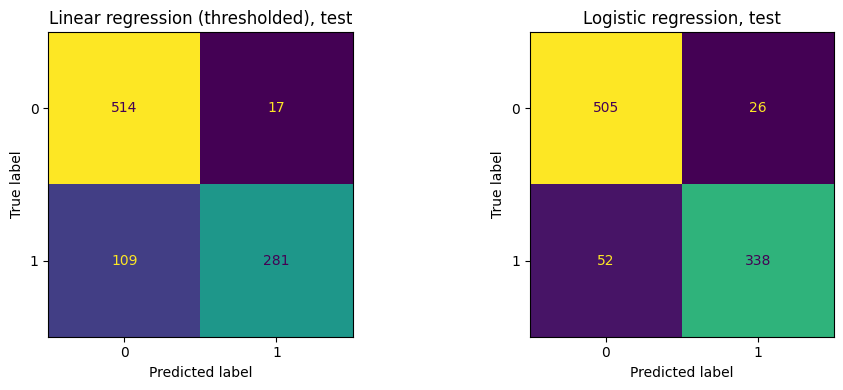

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

gd_cm = confusion_matrix(y_test_spam, spam_gd.predict(X_test_spam) >= 0.5)
ConfusionMatrixDisplay(gd_cm, display_labels=[0, 1]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Linear regression (thresholded), test")

lr_cm = confusion_matrix(y_test_spam, spam_lr.predict(X_test_spam))
ConfusionMatrixDisplay(lr_cm, display_labels=[0, 1]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Logistic regression, test")

plt.tight_layout()
plt.show()


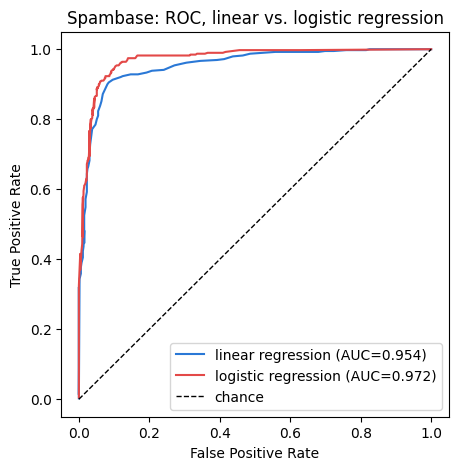

In [43]:
def roc_curve_manual(y_true, scores, n_thresholds=200):
    """Sweep thresholds across the scores' own range (works for both bounded probabilities and
    unbounded linear-regression outputs), then sort by FPR so trapezoid integration is valid."""
    thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)
    tprs, fprs = [], []
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        tprs.append(np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1))
        fprs.append(np.sum((y_true == 0) & (y_pred == 1)) / np.sum(y_true == 0))
    order = np.argsort(fprs)
    fprs, tprs = np.array(fprs)[order], np.array(tprs)[order]
    auc = np.trapezoid(tprs, fprs)
    return fprs, tprs, auc

fpr_gd, tpr_gd, auc_gd = roc_curve_manual(y_test_spam, spam_gd.decision_function(X_test_spam))
fpr_lr, tpr_lr, auc_lr = roc_curve_manual(y_test_spam, spam_lr.predict_proba(X_test_spam))

plt.figure(figsize=(5, 5))
plt.plot(fpr_gd, tpr_gd, color="#2a78d6", label=f"linear regression (AUC={auc_gd:.3f})")
plt.plot(fpr_lr, tpr_lr, color="#e34948", label=f"logistic regression (AUC={auc_lr:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spambase: ROC, linear vs. logistic regression")
plt.legend()
plt.show()


---
## Problem 2 — L1 / Lasso Regularization and Feature Selection

### (a) Spambase — what the assignment actually asks for

Sweep the L1 penalty, threshold the (real-valued) Lasso output at 0.5 for classification, and
look at two things together: does test accuracy hold up as the penalty grows, and how many
features does Lasso actually keep (nonzero coefficients) at each penalty level?


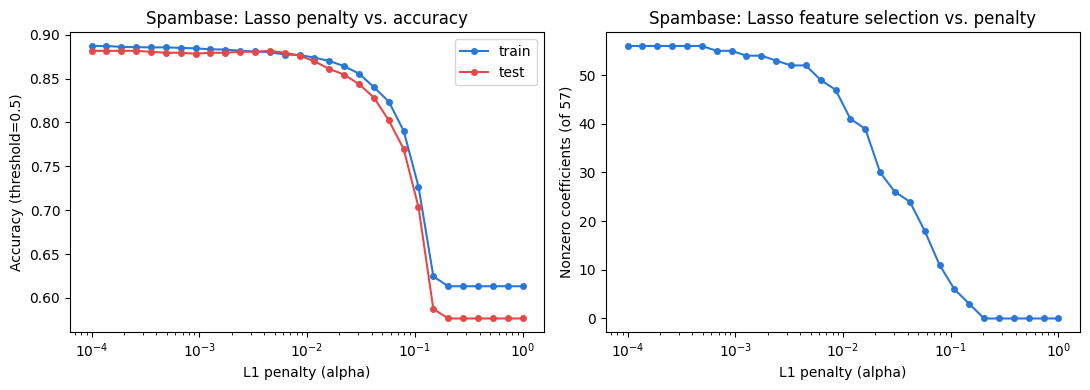

In [44]:
from sklearn.linear_model import Lasso

alphas = np.logspace(-4, 0, 30)
train_accs, test_accs, n_selected = [], [], []
for a in alphas:
    lasso_spam = Lasso(alpha=a).fit(X_train_spam, y_train_spam)  ### TODO_STUDENT ### fit sklearn's Lasso(alpha=a) on Spambase at this penalty value
    train_accs.append(accuracy_score(y_train_spam, lasso_spam.predict(X_train_spam) >= 0.5))  ### TODO_STUDENT ### threshold the Lasso prediction at 0.5 to get a class label, then compute train accuracy
    test_accs.append(accuracy_score(y_test_spam, lasso_spam.predict(X_test_spam) >= 0.5))  ### TODO_STUDENT ### threshold the Lasso prediction at 0.5 to get a class label, then compute test accuracy
    n_selected.append(np.sum(lasso_spam.coef_ != 0))  ### TODO_STUDENT ### count the number of nonzero (selected) coefficients at this penalty value

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(alphas, train_accs, color="#2a78d6", marker="o", markersize=4, label="train")
axes[0].plot(alphas, test_accs, color="#e34948", marker="o", markersize=4, label="test")
axes[0].set_xscale("log")
axes[0].set_xlabel("L1 penalty (alpha)")
axes[0].set_ylabel("Accuracy (threshold=0.5)")
axes[0].set_title("Spambase: Lasso penalty vs. accuracy")
axes[0].legend()

axes[1].plot(alphas, n_selected, color="#2a78d6", marker="o", markersize=4)
axes[1].set_xscale("log")
axes[1].set_xlabel("L1 penalty (alpha)")
axes[1].set_ylabel("Nonzero coefficients (of 57)")
axes[1].set_title("Spambase: Lasso feature selection vs. penalty")

plt.tight_layout()
plt.show()


### (b) Housing — penalty vs. train/test MSE

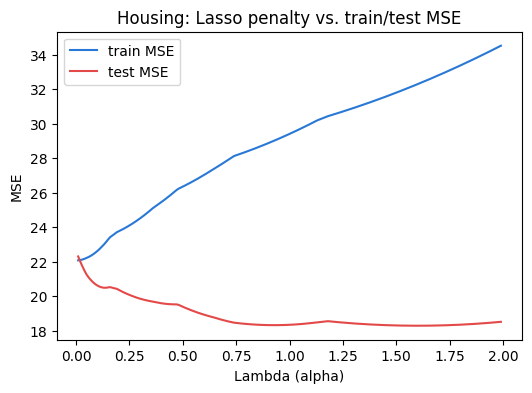

In [45]:
lasso_lambdas = np.arange(0.01, 2, 0.01)
train_mses, test_mses = [], []
for l in lasso_lambdas:
    lasso_house = Lasso(alpha=l, max_iter=10000).fit(X_train_housing, y_train_housing)
    train_mses.append(mse_loss(y_train_housing, lasso_house.predict(X_train_housing)))
    test_mses.append(mse_loss(y_test_housing, lasso_house.predict(X_test_housing)))

plt.figure(figsize=(6, 4))
plt.plot(lasso_lambdas, train_mses, color="#2a78d6", label="train MSE")
plt.plot(lasso_lambdas, test_mses, color="#e34948", label="test MSE")
plt.xlabel("Lambda (alpha)")
plt.ylabel("MSE")
plt.title("Housing: Lasso penalty vs. train/test MSE")
plt.legend()
plt.show()


### (c) 20 Newsgroups (8-class subset) — L1 feature selection on text

L1 logistic regression (one-vs-rest) ranks features by average |coefficient| across the 8
one-vs-rest classifiers; we keep the top 200 and refit an L2 logistic model on just those, then
report per-class and overall accuracy. (The course also has a local, pre-extracted
`data/20newsgroup.zip` / `data/8newsgroup.zip` for this -- either source works fine here, it isn't
an important detail for this HW, so we use the standard sklearn fetch for convenience.)


In [46]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

categories = [
    "rec.sport.hockey", "sci.space", "comp.graphics", "talk.politics.mideast",
    "alt.atheism", "soc.religion.christian", "misc.forsale", "rec.autos",
]
newsgroups = fetch_20newsgroups(subset="test", categories=categories, remove=("headers", "footers", "quotes"))

vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X_ng = vectorizer.fit_transform(newsgroups.data).toarray()
y_ng = newsgroups.target

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(X_ng, y_ng, test_size=0.2, random_state=42)
print("Newsgroups (8-class):", X_train_ng.shape, X_test_ng.shape)


Newsgroups (8-class): (2448, 3000) (613, 3000)


In [47]:
l1_log_reg = OneVsRestClassifier(LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000))
l1_log_reg.fit(X_train_ng, y_train_ng)

n_classes, n_features = len(l1_log_reg.estimators_), X_train_ng.shape[1]
subclassifier_coefs = np.zeros((n_classes, n_features))
for i, subclassifier in enumerate(l1_log_reg.estimators_):
    subclassifier_coefs[i, :] = np.abs(subclassifier.coef_)

average_coefs = np.mean(subclassifier_coefs, axis=0)
top_200 = np.argsort(-average_coefs)[:200]

X_train_ng200 = X_train_ng[:, top_200]
X_test_ng200 = X_test_ng[:, top_200]
print("Selected feature matrix:", X_train_ng200.shape)


Selected feature matrix: (2448, 200)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

In [48]:
l2_log_reg = OneVsRestClassifier(LogisticRegression(penalty="l2", max_iter=2000))
l2_log_reg.fit(X_train_ng200, y_train_ng)

y_train_pred = l2_log_reg.predict(X_train_ng200)
y_test_pred = l2_log_reg.predict(X_test_ng200)

for k, name in enumerate(newsgroups.target_names):
    mask_train, mask_test = y_train_ng == k, y_test_ng == k
    print(f"  {name:24s} train acc = {np.mean(y_train_pred[mask_train] == k):.3f}, "
          f"test acc = {np.mean(y_test_pred[mask_test] == k):.3f}")

print(f"Overall: train acc = {accuracy_score(y_train_ng, y_train_pred):.3f}, "
      f"test acc = {accuracy_score(y_test_ng, y_test_pred):.3f}")


  alt.atheism              train acc = 0.470, test acc = 0.412
  comp.graphics            train acc = 0.840, test acc = 0.780
  misc.forsale             train acc = 0.840, test acc = 0.744
  rec.autos                train acc = 0.873, test acc = 0.905
  rec.sport.hockey         train acc = 0.884, test acc = 0.814
  sci.space                train acc = 0.728, test acc = 0.787
  soc.religion.christian   train acc = 0.804, test acc = 0.683
  talk.politics.mideast    train acc = 0.824, test acc = 0.771
Overall: train acc = 0.792, test acc = 0.741


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

---
## Problem 3 — Perceptron from Scratch

Mistake-driven updates on a linearly-separable toy dataset (`perceptronData.txt`, 4 features + a
+-1 label). We track the number of mistakes made per full pass over the data; it should hit 0 once
the weight vector separates the classes.


In [49]:
perceptron_data = np.loadtxt(f"{DATA}/perceptronData.txt")
X_perceptron, y_perceptron = perceptron_data[:, :-1], perceptron_data[:, -1].astype(int)
print("Perceptron data:", X_perceptron.shape, y_perceptron.shape)


Perceptron data: (1000, 4) (1000,)


In [50]:
class MyPerceptron:
    """Classic mistake-driven perceptron: on a misclassified point, nudge theta toward its label."""

    def __init__(self, lr=1.0, epochs=100, bias=True):
        self.lr = lr
        self.epochs = epochs
        self.bias = bias
        self.theta = None

    def _add_bias(self, X):
        if X.ndim == 1:
            return np.insert(X, 0, 1.0) if self.bias else X
        n = X.shape[0]
        return np.concatenate([np.ones((n, 1)), X], axis=1) if self.bias else X

    def predict(self, X):
        return np.sign(self._add_bias(X) @ self.theta)  ### TODO_STUDENT ### classify by the sign of theta . x

    def fit(self, X, y):
        Xb = self._add_bias(X)
        n, m = Xb.shape
        rng = np.random.RandomState(0)
        self.theta = rng.normal(size=m)

        self.mistakes_per_epoch = []
        for epoch in range(self.epochs):
            mistakes = 0
            for xi, yi in zip(Xb, y):
                if yi * (xi @ self.theta) <= 0:  ### TODO_STUDENT ### detect a mistake: the point is misclassified if y*(theta.x) <= 0
                    mistakes += 1
                    self.theta = self.theta + self.lr * yi * xi  ### TODO_STUDENT ### apply the perceptron mistake-driven update rule
            self.mistakes_per_epoch.append(mistakes)
            if mistakes == 0:
                break
        return self


In [51]:
perceptron = MyPerceptron(lr=1.0, epochs=100).fit(X_perceptron, y_perceptron)

for epoch, mistakes in enumerate(perceptron.mistakes_per_epoch):
    print(f"  epoch {epoch + 1}: mistakes = {mistakes}")
print("Converged after", len(perceptron.mistakes_per_epoch), "epochs")
print("Final weight vector (bias first):", perceptron.theta)


  epoch 1: mistakes = 126
  epoch 2: mistakes = 68
  epoch 3: mistakes = 47
  epoch 4: mistakes = 68
  epoch 5: mistakes = 6
  epoch 6: mistakes = 2
  epoch 7: mistakes = 0
Converged after 7 epochs
Final weight vector (bias first): [-13.23594765   2.31637202   5.365211     8.11252542  10.75887214]


### Library baseline: sklearn `Perceptron`

The data is linearly separable, so both perceptrons should reach 0 training errors; we compare how
many epochs each needed, and whether the two separating hyperplanes point the same way.


In [52]:
from sklearn.linear_model import Perceptron as SkPerceptron

sk_perceptron = SkPerceptron().fit(X_perceptron, y_perceptron)  ### TODO_STUDENT ### fit sklearn's Perceptron as the library baseline
sk_train_acc = accuracy_score(y_perceptron, sk_perceptron.predict(X_perceptron))
scratch_train_acc = accuracy_score(y_perceptron, perceptron.predict(X_perceptron))

print(f"[library] sklearn Perceptron: train acc = {sk_train_acc:.3f}, converged in {sk_perceptron.n_iter_} epochs")
print(f"[scratch] our perceptron:    train acc = {scratch_train_acc:.3f}, "
      f"converged in {len(perceptron.mistakes_per_epoch)} epochs")

# Both encode the same separating hyperplane w.x + b = 0, just with the bias in a different slot
# (sklearn: [w1..w4, b]; ours: [b, w1..w4]) -- compare orientation via cosine similarity, not raw values.
sk_normal = np.append(sk_perceptron.coef_[0], sk_perceptron.intercept_[0])
scratch_normal = perceptron.theta[[1, 2, 3, 4, 0]]
cos_sim = (sk_normal @ scratch_normal) / (np.linalg.norm(sk_normal) * np.linalg.norm(scratch_normal))
print(f"Cosine similarity between the two separating hyperplanes: {cos_sim:.3f}")


[library] sklearn Perceptron: train acc = 1.000, converged in 9 epochs
[scratch] our perceptron:    train acc = 1.000, converged in 7 epochs
Cosine similarity between the two separating hyperplanes: 1.000


---
## Problem 4 — Gradient Boosting for Classification

### From-scratch weak learner: the HW1 `DecisionTree`

Reused verbatim from HW1 Problem 2 (`mode="regression"`, so it fits real-valued residuals rather
than class labels).


In [53]:
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # only set on leaves

    def is_leaf(self):
        return self.value is not None


def variance(y):
    if len(y) == 0:
        return 0.0
    return np.var(y)  ### TODO_STUDENT ### implement the variance (mean squared deviation from the mean) formula


def candidate_thresholds(column):
    values = np.unique(column)
    return (values[:-1] + values[1:]) / 2  ### TODO_STUDENT ### compute the midpoints between consecutive sorted unique values as candidate split thresholds


class DecisionTree:
    """Binary regression tree with threshold splits, grown by variance reduction. (Reused from
    HW1 Problem 2 -- only the regression mode is needed here.)"""

    def __init__(self, mode="regression", max_depth=5, min_samples_split=2):
        self.mode = mode
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def fit(self, X, y):
        self.root = self._grow(X, y, depth=0)
        return self

    def _leaf_value(self, y):
        return np.mean(y)  ### TODO_STUDENT ### return the mean target value among this leaf's points

    def _grow(self, X, y, depth):
        n, m = X.shape
        if depth >= self.max_depth or len(np.unique(y)) == 1 or n < self.min_samples_split:  ### TODO_STUDENT ### decide when to stop splitting and turn this node into a leaf
            return TreeNode(value=self._leaf_value(y))

        parent_impurity = variance(y)
        best_gain, best_feature, best_threshold = 0.0, None, None

        for feature in range(m):
            for threshold in candidate_thresholds(X[:, feature]):
                left_mask = X[:, feature] <= threshold  ### TODO_STUDENT ### define which points fall left vs. right of this candidate threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:  ### TODO_STUDENT ### skip candidate thresholds that would leave one side empty
                    continue
                y_left, y_right = y[left_mask], y[right_mask]
                weighted_child_impurity = (np.var(y_left) * np.sum(left_mask) + np.var(y_right) * np.sum(right_mask)) / n  ### TODO_STUDENT ### weight each child's variance by the fraction of the parent's points it received
                gain = parent_impurity - weighted_child_impurity  ### TODO_STUDENT ### compute the variance-reduction gain of this candidate split
                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature, threshold  ### TODO_STUDENT ### keep track of the best (feature, threshold) split seen so far

        if best_feature is None:
            return TreeNode(value=self._leaf_value(y))

        left_mask = X[:, best_feature] <= best_threshold  ### TODO_STUDENT ### recompute the partition using the winning (best_feature, best_threshold) before recursing
        right_mask = ~left_mask
        left = self._grow(X[left_mask], y[left_mask], depth + 1)  ### TODO_STUDENT ### recursively grow the left subtree on the left split
        right = self._grow(X[right_mask], y[right_mask], depth + 1)  ### TODO_STUDENT ### recursively grow the right subtree on the right split
        return TreeNode(feature=best_feature, threshold=best_threshold, left=left, right=right)

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        branch = node.left if x[node.feature] <= node.threshold else node.right  ### TODO_STUDENT ### walk left or right at this node based on the split threshold
        return self._predict_one(x, branch)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


### Core: binary gradient boosting (Spambase)

Maintain an accumulated score F(x); the probability is p(x) = sigmoid(F(x)). Each round, fit a
shallow regression tree to the pseudo-residuals r = y - p(x), and add it to F.


In [54]:
class GradientBoostBinaryClassifier:
    def __init__(self, n_rounds=60, tree_depth=2):
        self.n_rounds = n_rounds
        self.tree_depth = tree_depth

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))  ### TODO_STUDENT ### implement the sigmoid function

    def fit(self, X, y):
        self.trees = []
        F = np.zeros(X.shape[0])
        for _ in range(self.n_rounds):
            residual = y - self.sigmoid(F)  ### TODO_STUDENT ### compute the pseudo-residual r = y - sigmoid(F(x))
            tree = DecisionTree(mode="regression", max_depth=self.tree_depth).fit(X, residual)  ### TODO_STUDENT ### fit a shallow regression tree to the current pseudo-residuals
            self.trees.append(tree)
            F = F + tree.predict(X)  ### TODO_STUDENT ### accumulate this round's tree prediction into the running score F
        return self

    def decision_function(self, X):
        F = np.zeros(X.shape[0])
        for tree in self.trees:
            F = F + tree.predict(X)  ### TODO_STUDENT ### accumulate every tree's prediction into the total score F
        return F

    def predict_proba(self, X):
        """p(y=1|x) = sigmoid(F(x))."""
        return self.sigmoid(self.decision_function(X))  ### TODO_STUDENT ### convert the accumulated score F(x) into a probability via sigmoid

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)  ### TODO_STUDENT ### threshold the predicted probability into a 0/1 class label

    def staged_decision_function(self, X):
        """Yield F(x) after each additional tree (for the T-sweep plot)."""
        F = np.zeros(X.shape[0])
        for tree in self.trees:
            F = F + tree.predict(X)  ### TODO_STUDENT ### accumulate this round's tree prediction into the running score F
            yield F


In [55]:
n_rounds = 60
gb_spam = GradientBoostBinaryClassifier(n_rounds=n_rounds, tree_depth=2).fit(X_train_spam, y_train_spam)

train_err, test_err = [], []
for F_train, F_test in zip(gb_spam.staged_decision_function(X_train_spam),
                            gb_spam.staged_decision_function(X_test_spam)):
    train_err.append(1 - accuracy_score(y_train_spam, gb_spam.sigmoid(F_train) >= 0.5))
    test_err.append(1 - accuracy_score(y_test_spam, gb_spam.sigmoid(F_test) >= 0.5))

print(f"[scratch] Spambase boosting, final (T={n_rounds}): train err = {train_err[-1]:.3f}, test err = {test_err[-1]:.3f}")


[scratch] Spambase boosting, final (T=60): train err = 0.053, test err = 0.058


### Library baseline: sklearn `GradientBoostingClassifier`

Same tree depth (2) and an unshrunk step (`learning_rate=1.0`, matching our from-scratch version's
full step each round) so the two curves are directly comparable round-for-round.


[library] Spambase boosting, final (T=60): train err = 0.020, test err = 0.059


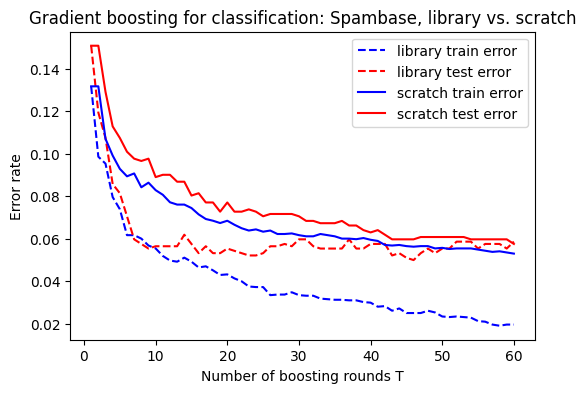

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

sk_gbc_spam = GradientBoostingClassifier(
    loss="log_loss", n_estimators=n_rounds, max_depth=2, learning_rate=1.0, random_state=0
).fit(X_train_spam, y_train_spam)  ### TODO_STUDENT ### fit sklearn's GradientBoostingClassifier(loss='log_loss') as the library baseline

lib_train_err = [1 - accuracy_score(y_train_spam, pred) for pred in sk_gbc_spam.staged_predict(X_train_spam)]
lib_test_err = [1 - accuracy_score(y_test_spam, pred) for pred in sk_gbc_spam.staged_predict(X_test_spam)]
print(f"[library] Spambase boosting, final (T={n_rounds}): train err = {lib_train_err[-1]:.3f}, test err = {lib_test_err[-1]:.3f}")

plt.figure(figsize=(6, 4))
rounds = range(1, n_rounds + 1)
plt.plot(rounds, lib_train_err, "b--", label="library train error")
plt.plot(rounds, lib_test_err, "r--", label="library test error")
plt.plot(rounds, train_err, "b-", label="scratch train error")
plt.plot(rounds, test_err, "r-", label="scratch test error")
plt.xlabel("Number of boosting rounds T")
plt.ylabel("Error rate")
plt.title("Gradient boosting for classification: Spambase, library vs. scratch")
plt.legend()
plt.show()


### Stretch: multiclass boosting on 20 Newsgroups (8-class)

Same pseudo-residual idea generalized to K classes via softmax over K accumulated scores, one
weak learner per class per round. Reuses the 8-class Newsgroups data already loaded in Problem 2c
-- no new fetch, no new training data. The weak learner here is sklearn's
`DecisionTreeRegressor(max_depth=1)` rather than our from-scratch `DecisionTree`: with ~3000 TF-IDF
features, the from-scratch tree's plain-Python double loop over every feature and every candidate
threshold would be far too slow to run `n_estimators` times per class.


In [57]:
from sklearn.tree import DecisionTreeRegressor

class MyGradientBoostClassifier:
    def __init__(self, n_estimators=100, lr=0.5):
        self.n_estimators = n_estimators
        self.lr = lr

    def fit(self, X, y):
        n = X.shape[0]
        self.n_classes = len(np.unique(y))
        F = np.zeros((n, self.n_classes))
        self.weak_learners = [[DecisionTreeRegressor(max_depth=1) for _ in range(self.n_classes)]
                               for _ in range(self.n_estimators)]

        for t in range(self.n_estimators):
            exp_F = np.exp(F - F.max(axis=1, keepdims=True))
            softmax = exp_F / exp_F.sum(axis=1, keepdims=True)  ### TODO_STUDENT ### convert the K accumulated scores into class probabilities via softmax
            for k in range(self.n_classes):
                residual_k = (y == k).astype(float) - softmax[:, k]  ### TODO_STUDENT ### compute class k's pseudo-residual: (y == k) - p_k
                self.weak_learners[t][k].fit(X, residual_k)  ### TODO_STUDENT ### fit class k's weak learner to its pseudo-residual
                F[:, k] += self.lr * self.weak_learners[t][k].predict(X)  ### TODO_STUDENT ### accumulate this round's prediction into class k's running score
        return self

    def decision_function(self, X):
        n = X.shape[0]
        F = np.zeros((n, self.n_classes))
        for t in range(self.n_estimators):
            for k in range(self.n_classes):
                F[:, k] += self.lr * self.weak_learners[t][k].predict(X)  ### TODO_STUDENT ### accumulate every round's prediction into class k's total score
        return F

    def predict(self, X):
        F = self.decision_function(X)
        return np.argmax(F, axis=1)  ### TODO_STUDENT ### predict the class with the highest accumulated score


In [58]:
gb_clf_ng = MyGradientBoostClassifier(n_estimators=150, lr=0.6).fit(X_train_ng, y_train_ng)

acc_train = accuracy_score(y_train_ng, gb_clf_ng.predict(X_train_ng))
acc_test = accuracy_score(y_test_ng, gb_clf_ng.predict(X_test_ng))
print(f"[stretch] Newsgroups (8-class) boosting: train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[stretch] Newsgroups (8-class) boosting: train acc = 0.867, test acc = 0.759


### Library baseline: sklearn `GradientBoostingClassifier` (multiclass)

`GradientBoostingClassifier` supports multiclass natively (it also fits one weak learner per class
per round internally), so it's a direct library counterpart for this stretch too -- same weak-learner
depth (1) and learning rate (0.6) as our from-scratch version, for a like-for-like comparison.


In [59]:
sk_gbc_ng = GradientBoostingClassifier(
    loss="log_loss", n_estimators=150, max_depth=1, learning_rate=0.6, random_state=0
).fit(X_train_ng, y_train_ng)  ### TODO_STUDENT ### fit sklearn's GradientBoostingClassifier as the multiclass library baseline

acc_train_lib = accuracy_score(y_train_ng, sk_gbc_ng.predict(X_train_ng))
acc_test_lib = accuracy_score(y_test_ng, sk_gbc_ng.predict(X_test_ng))
print(f"[library] Newsgroups (8-class) boosting: train acc = {acc_train_lib:.3f}, test acc = {acc_test_lib:.3f}")


[library] Newsgroups (8-class) boosting: train acc = 0.975, test acc = 0.703


---
## Problem 5 — Active Learning (Uncertainty Sampling)

One pool-based loop, reused for two base classifiers built above. Both classifiers expose a
`predict_proba` that returns p(y=1|x), so the same "distance from 0.5" uncertainty measure works
for both:

- **(a) gradient-boosted trees** (Problem 4 core) -- uncertainty = |sigmoid(F(x)) - 0.5|
- **(b) logistic regression** (Problem 1) -- uncertainty = |p(y|x) - 0.5|

Each round we retrain the classifier from scratch on the currently-labeled set, so the boosting
model here uses fewer rounds (15, vs. 60 above) purely to keep the repeated retraining fast --
the active-learning *loop* is the point being tested, not a fully-tuned boosted model.


In [60]:
def margin_uncertainty(model, X):
    return np.abs(model.predict_proba(X) - 0.5)  ### TODO_STUDENT ### define uncertainty as distance from the decision threshold 0.5


def active_learning_curve(model_factory, X_pool, y_pool, X_test, y_test,
                           n_seed=60, n_query=20, n_rounds=15, strategy="uncertainty", seed=0):
    rng = np.random.RandomState(seed)
    order = rng.permutation(len(X_pool))
    labeled = list(order[:n_seed])
    unlabeled = list(order[n_seed:])

    n_labeled_list, accs = [], []
    for _ in range(n_rounds):
        model = model_factory().fit(X_pool[labeled], y_pool[labeled])  ### TODO_STUDENT ### retrain the classifier from scratch on the currently-labeled set
        accs.append(accuracy_score(y_test, model.predict(X_test)))
        n_labeled_list.append(len(labeled))

        if not unlabeled:
            break
        if strategy == "uncertainty":
            scores = margin_uncertainty(model, X_pool[unlabeled])
            chosen = list(np.argsort(scores)[:n_query]) ### TODO_STUDENT ### select the n_query least-certain (smallest-margin) unlabeled points
        else:
            chosen = list(rng.choice(len(unlabeled), size=min(n_query, len(unlabeled)), replace=False))

        chosen_global = [unlabeled[i] for i in chosen]
        labeled.extend(chosen_global)
        chosen_set = set(chosen_global)
        unlabeled = [i for i in unlabeled if i not in chosen_set]

    return n_labeled_list, accs


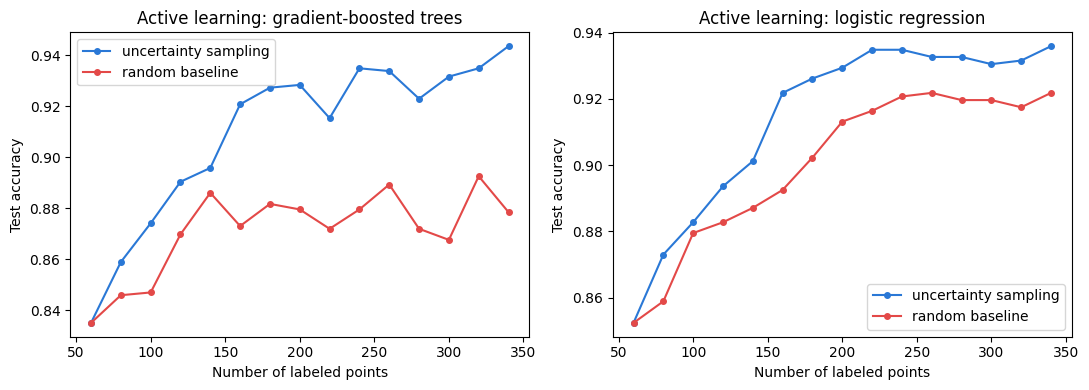

In [61]:
gb_factory = lambda: GradientBoostBinaryClassifier(n_rounds=15, tree_depth=2)
logreg_factory = lambda: MyLogReg(lr=0.1, epochs=3000)

n_gb_active, acc_gb_active = active_learning_curve(gb_factory, X_train_spam, y_train_spam, X_test_spam, y_test_spam, strategy="uncertainty")
n_gb_random, acc_gb_random = active_learning_curve(gb_factory, X_train_spam, y_train_spam, X_test_spam, y_test_spam, strategy="random")

n_lr_active, acc_lr_active = active_learning_curve(logreg_factory, X_train_spam, y_train_spam, X_test_spam, y_test_spam, strategy="uncertainty")
n_lr_random, acc_lr_random = active_learning_curve(logreg_factory, X_train_spam, y_train_spam, X_test_spam, y_test_spam, strategy="random")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(n_gb_active, acc_gb_active, color="#2a78d6", marker="o", markersize=4, label="uncertainty sampling")
axes[0].plot(n_gb_random, acc_gb_random, color="#e34948", marker="o", markersize=4, label="random baseline")
axes[0].set_xlabel("Number of labeled points")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Active learning: gradient-boosted trees")
axes[0].legend()

axes[1].plot(n_lr_active, acc_lr_active, color="#2a78d6", marker="o", markersize=4, label="uncertainty sampling")
axes[1].plot(n_lr_random, acc_lr_random, color="#e34948", marker="o", markersize=4, label="random baseline")
axes[1].set_xlabel("Number of labeled points")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Active learning: logistic regression")
axes[1].legend()

plt.tight_layout()
plt.show()


### Which classifier benefits more from active selection?

*(Fill in after running: compare how far above the random baseline each uncertainty-sampling curve
sits, and at what labeling budget the gap is largest.)*

Gradient-boosted trees benefit more from active selection. The gap between uncertainty sampling and the random baseline is both larger and appears earlier — it's already visible around 100-120 labeled points and stays substantial (roughly 5-7 percentage points) through most of the budget. Logistic regression also benefits, but the gap is narrower and starts closing again by around 300+ labeled points, as random sampling catches up. This makes sense since boosted trees are more flexible and can exploit a well-chosen uncertain point more effectively than a single linear decision boundary can.


### Theory Question 6: Why L1 Zeroes Coefficients and L2 Doesn't?

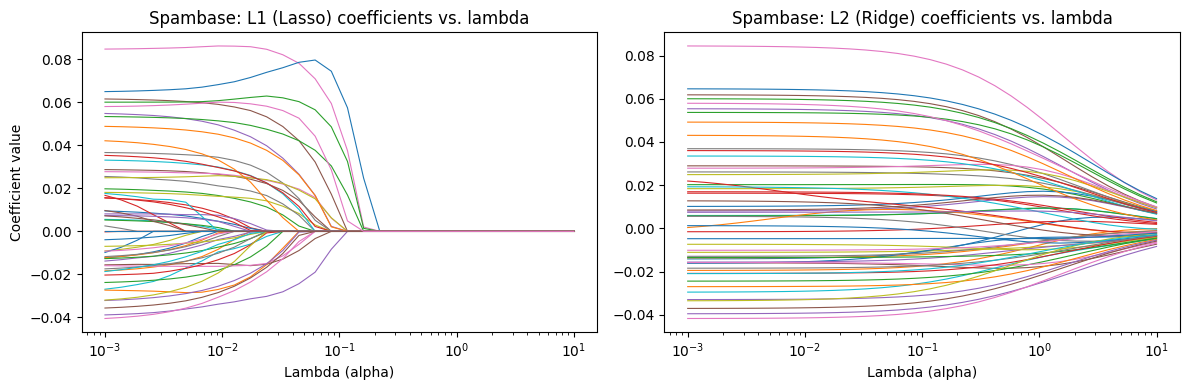

In [33]:
from sklearn.linear_model import Ridge as RidgeCoefCheck

lambdas_coef = np.logspace(-3, 1, 30)
lasso_coefs = []
ridge_coefs = []

for l in lambdas_coef:
    lasso_fit = Lasso(alpha=l, max_iter=10000).fit(X_train_spam, y_train_spam)
    ridge_fit = RidgeCoefCheck(alpha=l * X_train_spam.shape[0]).fit(X_train_spam, y_train_spam)
    lasso_coefs.append(lasso_fit.coef_)
    ridge_coefs.append(ridge_fit.coef_)

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j in range(lasso_coefs.shape[1]):
    axes[0].plot(lambdas_coef, lasso_coefs[:, j], linewidth=0.8)
    axes[1].plot(lambdas_coef, ridge_coefs[:, j], linewidth=0.8)
axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[0].set_xlabel("Lambda (alpha)")
axes[1].set_xlabel("Lambda (alpha)")
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Spambase: L1 (Lasso) coefficients vs. lambda")
axes[1].set_title("Spambase: L2 (Ridge) coefficients vs. lambda")
plt.tight_layout()
plt.show()

Using the Above graphs as reference,

L1 and L2 behave differently near zero because of how their penalties are shaped. Ridge's penalty (λθ²) weakens as θ gets smaller, so it keeps shrinking a coefficient but never quite finishes the job. Lasso's penalty (λ|θ|) stays constant no matter how small θ already is, so it has enough steady pressure to push small coefficients all the way to exactly zero.

Test accuracy eventually drops because a large λ forces the model to drop or shrink too many features, including ones that were actually useful. A moderate penalty helps by removing noise and preventing overfitting, but too much penalty leaves the model too simple to capture the real pattern in the data.

### Thoery Question 7: ROC Curve Shape vs. AUC for a Screening Application

I'd choose the classifier whose ROC curve rises steeply at low FPR and levels off. For a screening test, you need to operate near the low-FPR end anyway, since you can't tolerate flagging too many healthy people as positive — and in that exact region, the steep-rising classifier catches far more true positives per false positive than the gradual one does. The other classifier may "catch up" at higher FPR, but that part of its curve isn't usable here. AUC alone can't show this because it's just one number summarizing the whole curve — two curves can enclose the same total area while having very different shapes, so identical AUC can hide the fact that one classifier is actually much better specifically in the low-FPR region that matters for this application.

---
## Problem 6 (optional) — Lasso from Scratch (Coordinate Descent)

L1 isn't differentiable at 0, so Lasso isn't fit by plain gradient descent -- the standard
from-scratch approach is **coordinate descent**: cycle through features j = 1..m, and at each one
compute the partial residual r_j = y - Xtheta + theta_j*x_j (i.e. the residual if feature j's
contribution were removed), its correlation with feature j (rho_j = x_j . r_j), and update

theta_j <- soft_threshold(rho_j / ||x_j||^2, alpha_eff / ||x_j||^2),  soft_threshold(z,t) = sign(z)*max(|z|-t, 0)

Sweep until the largest coordinate change in a sweep drops below a tolerance. One normalization
detail: sklearn's `Lasso(alpha=...)` minimizes `(1/(2n))*sum-squared-error + alpha*||w||_1`, while
the soft-threshold update above comes from the *un-normalized* `(1/2)*sum-squared-error +
alpha_eff*||w||_1` -- so to match a given sklearn `alpha`, we solve with `alpha_eff = alpha * n`
internally (same normalization fix as Problem 1's Ridge-vs-GD comparison).


In [ ]:
class LassoCoordinateDescent:
    """Lasso fit by cyclic coordinate descent. `alpha` uses sklearn's convention; internally we
    solve the equivalent un-normalized problem the soft-threshold update assumes."""

    def __init__(self, alpha=1.0, max_sweeps=2000, tol=1e-6):
        self.alpha = alpha
        self.max_sweeps = max_sweeps
        self.tol = tol

    def soft_threshold(self, z, t):
        return np....  ### TODO_STUDENT ### implement the soft-thresholding operator, sign(z)*max(|z|-t, 0)

    def fit(self, X, y):
        n, m = X.shape
        self.y_mean_ = y.mean()
        y_centered = y - self.y_mean_  # X is already mean-0 (standardized), so centering y alone
        effective_alpha = self.alpha * n  # gives an intercept-free fit equivalent to sklearn's
        col_norm_sq = np.sum(X ** 2, axis=0)

        theta = np.zeros(m)
        pred = X @ theta  # kept in sync with theta as we go, so each update is O(n) not O(nm)

        for sweep in range(self.max_sweeps):
            max_change = 0.0
            for j in range(m):
                if col_norm_sq[j] == 0:
                    continue
                r_j = ...  ### TODO_STUDENT ### compute the partial residual with feature j's own contribution removed
                rho_j = ...  ### TODO_STUDENT ### compute feature j's correlation with the partial residual
                theta_j_new = self.soft_threshold...  ### TODO_STUDENT ### apply the coordinate-descent soft-threshold update for theta_j
                delta = theta_j_new - theta[j]
                if delta != 0.0:
                    pred = ...  ### TODO_STUDENT ### keep the running prediction in sync with the updated theta_j
                max_change = max(max_change, abs(delta))
                theta[j] = theta_j_new
            if ...:  ### TODO_STUDENT ### check for convergence: stop once no coordinate changes by more than the tolerance
                break

        self.n_sweeps_ = sweep + 1
        self.theta = theta
        return self

    def predict(self, X):
        return self.y_mean_ + X @ self.theta


### Verification against sklearn's `Lasso`, at a handful of alphas spanning Problem 2a's sweep

In [ ]:
test_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]

for a in test_alphas:
    sk_lasso = Lasso(alpha=a, max_iter=10000).fit(X_train_spam, y_train_spam)
    my_lasso = LassoCoordinateDescent(alpha=a).fit(X_train_spam, y_train_spam)

    coef_diff = np.linalg.norm(sk_lasso.coef_ - my_lasso.theta)
    acc_sk = accuracy_score(y_test_spam, sk_lasso.predict(X_test_spam) >= 0.5)
    acc_mine = accuracy_score(y_test_spam, my_lasso.predict(X_test_spam) >= 0.5)
    nnz_sk = int(np.sum(np.abs(sk_lasso.coef_) > 1e-8))
    nnz_mine = int(np.sum(np.abs(my_lasso.theta) > 1e-8))

    print(f"alpha={a:<8} coef diff (L2 norm) = {coef_diff:.6f}, sweeps = {my_lasso.n_sweeps_:>4} | "
          f"test acc  sklearn={acc_sk:.3f}  scratch={acc_mine:.3f} | "
          f"nonzero coefs  sklearn={nnz_sk:>2}  scratch={nnz_mine:>2}")
